# Experiment: Naive Bayes Text Classification

## 20 Newsgroups Dataset

Implementation and comparison of:

- Multinomial Naive Bayes
- Bernoulli Naive Bayes

# Naive Bayes Text Classification — 20 Newsgroups

## Aim

To implement and compare **Multinomial Naive Bayes** and **Bernoulli Naive Bayes**
for text classification using the **20 Newsgroups dataset**.

### Tasks
- Load and preprocess the 20 Newsgroups dataset
- Convert text into numerical features using CountVectorizer
- Implement Multinomial Naive Bayes
- Implement Bernoulli Naive Bayes
- Compare both models using Accuracy and Weighted F1-score

In [1]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, f1_score, classification_report

#Load the dataset

In [2]:
remove = ('headers', 'footers', 'quotes')

train = fetch_20newsgroups(
    subset='train',
    remove=remove
)

test = fetch_20newsgroups(
    subset='test',
    remove=remove
)

X_train = train.data
y_train = train.target

X_test = test.data
y_test = test.target

print("Training documents:", len(X_train))
print("Testing documents:", len(X_test))
print("Number of classes:", len(train.target_names))

Training documents: 11314
Testing documents: 7532
Number of classes: 20


#Inspect a sample

In [3]:
i = 0

print("Class:", train.target_names[y_train[i]])
print()
print(X_train[i][:800])

Class: rec.autos

I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


#Convert text to numbers


In [4]:
vectorizer = CountVectorizer(stop_words='english')

X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

print("Training shape:", X_train_counts.shape)
print("Testing shape:", X_test_counts.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))

Training shape: (11314, 101322)
Testing shape: (7532, 101322)
Vocabulary size: 101322


#**Multinomial Naive Bayes**

##Train Multinomial NB

In [5]:
multinomial_model = MultinomialNB()

multinomial_model.fit(X_train_counts, y_train)

y_pred_m = multinomial_model.predict(X_test_counts)

##Evaluate Multinomial NB

In [6]:
m_accuracy = accuracy_score(y_test, y_pred_m)
m_f1 = f1_score(y_test, y_pred_m, average='weighted')

print("Multinomial Naive Bayes")
print("Accuracy:", m_accuracy)
print("Weighted F1-score:", m_f1)

Multinomial Naive Bayes
Accuracy: 0.6343600637280935
Weighted F1-score: 0.6095621937424516


#**Bernoulli Naive Bayes**

##Binary representation

In [7]:
binary_vectorizer = CountVectorizer(
    stop_words='english',
    binary=True
)

X_train_binary = binary_vectorizer.fit_transform(X_train)
X_test_binary = binary_vectorizer.transform(X_test)

print("Training shape:", X_train_binary.shape)
print("Testing shape:", X_test_binary.shape)

Training shape: (11314, 101322)
Testing shape: (7532, 101322)


##Train Bernoulli NB

In [8]:
bernoulli_model = BernoulliNB()

bernoulli_model.fit(X_train_binary, y_train)

y_pred_b = bernoulli_model.predict(X_test_binary)

##Evaluate Bernoulli NB

In [9]:
b_accuracy = accuracy_score(y_test, y_pred_b)
b_f1 = f1_score(y_test, y_pred_b, average='weighted')

print("Bernoulli Naive Bayes")
print("Accuracy:", b_accuracy)
print("Weighted F1-score:", b_f1)

Bernoulli Naive Bayes
Accuracy: 0.4584439723844928
Weighted F1-score: 0.44917453119335515


#**Compare the models**

In [10]:
print("Model Comparison")
print("-" * 40)

print(f"Multinomial NB Accuracy : {m_accuracy:.4f}")
print(f"Multinomial NB F1-score : {m_f1:.4f}")

print()

print(f"Bernoulli NB Accuracy   : {b_accuracy:.4f}")
print(f"Bernoulli NB F1-score   : {b_f1:.4f}")

Model Comparison
----------------------------------------
Multinomial NB Accuracy : 0.6344
Multinomial NB F1-score : 0.6096

Bernoulli NB Accuracy   : 0.4584
Bernoulli NB F1-score   : 0.4492


##Classification Report

In [11]:
print("Multinomial Naive Bayes Classification Report")
print(
    classification_report(
        y_test,
        y_pred_m,
        target_names=train.target_names
    )
)

Multinomial Naive Bayes Classification Report
                          precision    recall  f1-score   support

             alt.atheism       0.65      0.30      0.41       319
           comp.graphics       0.58      0.69      0.63       389
 comp.os.ms-windows.misc       0.40      0.01      0.01       394
comp.sys.ibm.pc.hardware       0.53      0.72      0.61       392
   comp.sys.mac.hardware       0.74      0.56      0.64       385
          comp.windows.x       0.56      0.81      0.66       395
            misc.forsale       0.85      0.69      0.76       390
               rec.autos       0.82      0.70      0.76       396
         rec.motorcycles       0.91      0.62      0.73       398
      rec.sport.baseball       0.94      0.74      0.83       397
        rec.sport.hockey       0.58      0.91      0.71       399
               sci.crypt       0.54      0.79      0.64       396
         sci.electronics       0.71      0.49      0.58       393
                 sci.med     

#**Example Prediction**

In [12]:
examples = [
    "NASA launched a spacecraft into orbit",
    "The baseball team won the game",
    "My computer graphics card is not working"
]

for text in examples:
    X = vectorizer.transform([text])
    prediction = multinomial_model.predict(X)[0]

    print("Text:", text)
    print("Predicted class:", train.target_names[prediction])
    print()

Text: NASA launched a spacecraft into orbit
Predicted class: sci.space

Text: The baseball team won the game
Predicted class: rec.sport.baseball

Text: My computer graphics card is not working
Predicted class: comp.graphics



#**VISUALIZATION**

## Visualization — Model Performance

Compare the Accuracy and Weighted F1-score of Multinomial and Bernoulli Naive Bayes.

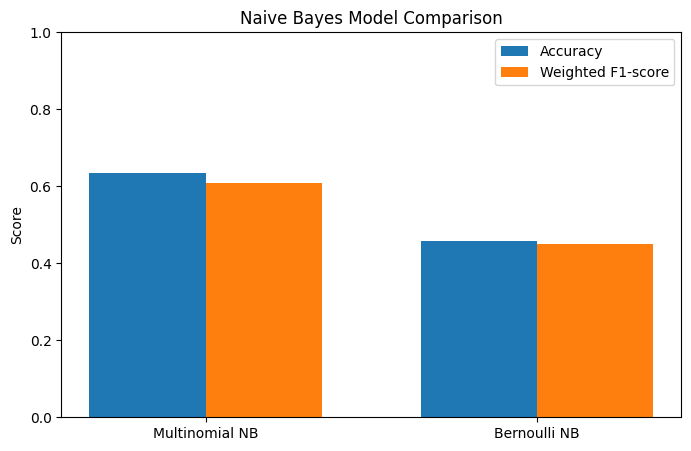

In [13]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Multinomial NB', 'Bernoulli NB']
accuracy = [m_accuracy, b_accuracy]
f1 = [m_f1, b_f1]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, accuracy, width, label='Accuracy')
plt.bar(x + width/2, f1, width, label='Weighted F1-score')

plt.xticks(x, models)
plt.ylabel('Score')
plt.title('Naive Bayes Model Comparison')
plt.ylim(0, 1)
plt.legend()

plt.show()

## Confusion Matrix — Multinomial Naive Bayes

The confusion matrix shows the actual classes against the classes predicted
by the Multinomial Naive Bayes classifier.

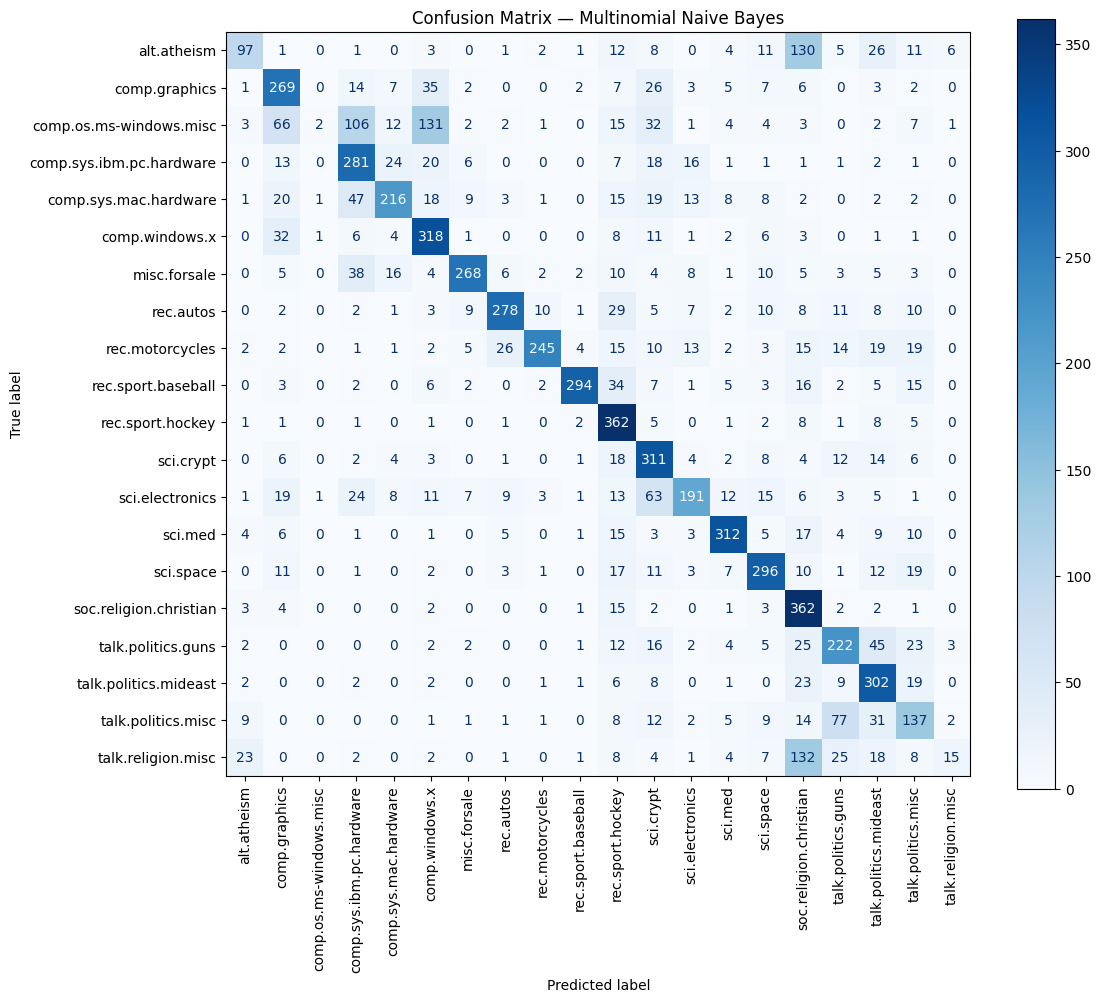

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_m = confusion_matrix(y_test, y_pred_m)

plt.figure(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_m,
    display_labels=train.target_names
)

disp.plot(
    xticks_rotation=90,
    cmap='Blues',
    ax=plt.gca()
)

plt.title('Confusion Matrix — Multinomial Naive Bayes')
plt.show()

## Confusion Matrix — Bernoulli Naive Bayes

The confusion matrix shows how well the Bernoulli Naive Bayes classifier
distinguishes between the 20 newsgroup classes.

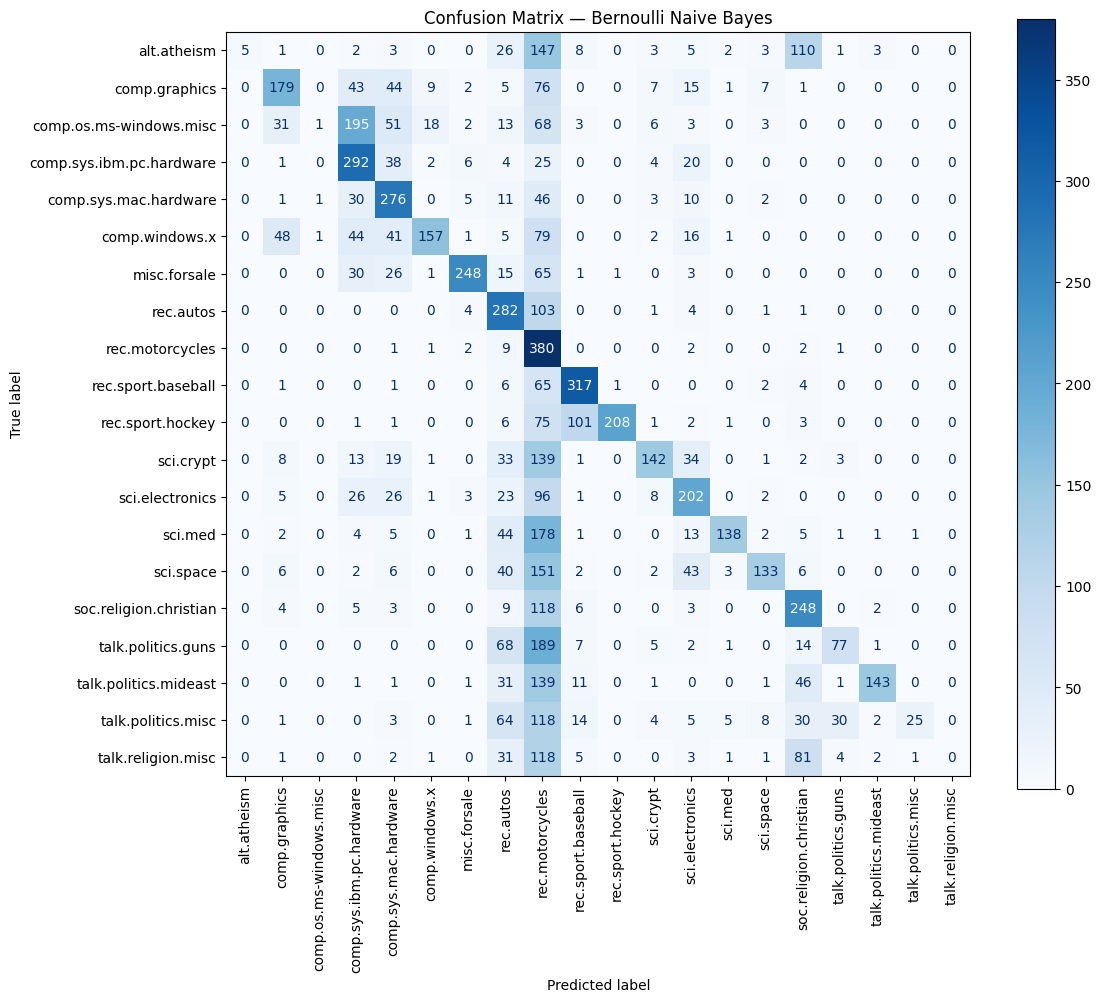

In [18]:
cm_b = confusion_matrix(y_test, y_pred_b)

plt.figure(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_b,
    display_labels=train.target_names
)

disp.plot(
    xticks_rotation=90,
    cmap='Blues',
    ax=plt.gca()
)

plt.title('Confusion Matrix — Bernoulli Naive Bayes')
plt.show()

## Conclusion

- Multinomial Naive Bayes uses **word frequency/counts**.
- Bernoulli Naive Bayes uses **word presence or absence**.
- Multinomial NB can benefit when repeated words provide stronger evidence.
- Bernoulli NB ignores how many times a word occurs.
- Both models are fast and work well with high-dimensional text data.
- The better model depends on the dataset and feature representation.

### Result

The model with the higher **Accuracy and Weighted F1-score** performed better
for this experiment.